In [2]:
%pip install -q pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)
sns.set_theme(style="whitegrid")

In [21]:
train_df=pd.read_csv("titanic_train_encoded.csv")
test_df=pd.read_csv("titanic_test_encoded.csv")

In [22]:
train_df.shape

(712, 19)

In [25]:
target="survived"
X_train=train_df.drop(columns=[target])
y_train=train_df[target]

X_test=test_df.drop(columns=[target])
y_test=test_df[target]

In [27]:
X_train.shape

(712, 18)

In [24]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G
0,3,1,28.5,0,0,56.4958,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,1,28.5,0,0,0.0000,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,1,28.5,0,0,221.7792,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3,0,18.0,0,1,9.3500,0,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2,0,31.0,1,1,26.2500,0,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [18]:
y_train.head()

0    0
1    0
2    1
3    0
4    1
Name: survived, dtype: int64

In [28]:
print(X_train.shape)
print(X_test.shape)


(712, 18)
(179, 18)


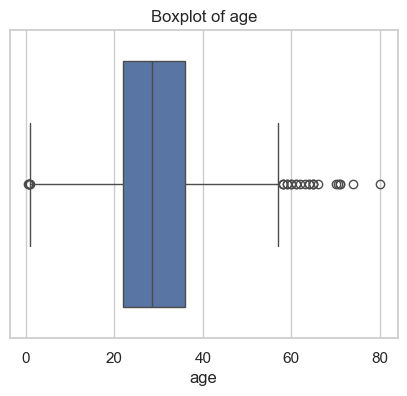

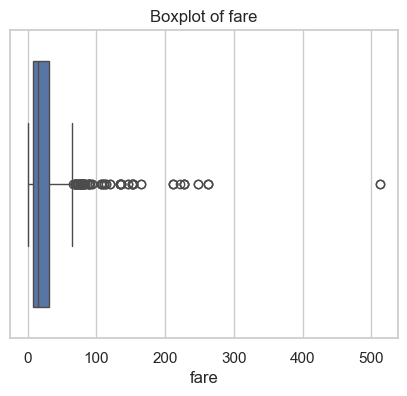

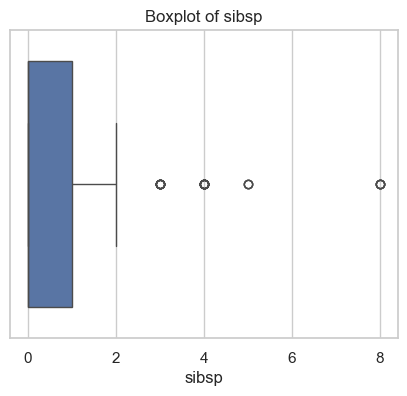

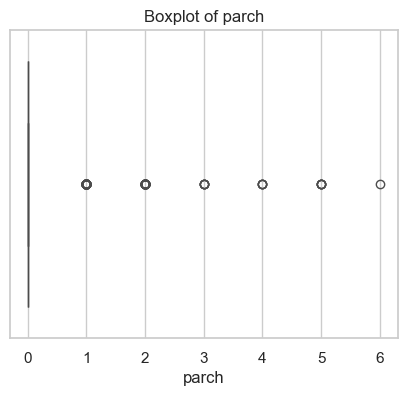

In [30]:
nums_cols=["age","fare","sibsp","parch"]
for col in nums_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [31]:
valid_outlier_cols=["age","fare"]

function for iqr


In [32]:
def iqr_bound(series,factor=1.5):
    q1=series.quantile(0.25)
    q3=series.quantile(0.75)
    iqr=q3-q1
    
    lower_bound=q1-factor*iqr
    upper_bound=q3+factor*iqr
    return lower_bound,upper_bound
    
    
    

In [37]:
def compute_train_bounds(df,cols):
    bounds={}
    for col in cols:
        low,high=iqr_bound(df[col])
        bounds[col]={low,high}
    return bounds

In [38]:
print(compute_train_bounds(X_train,valid_outlier_cols))

{'age': {np.float64(1.0), np.float64(57.0)}, 'fare': {np.float64(65.6563), np.float64(-26.7605)}}


In [53]:
#apply the same bound in any set
def cap_outlier_with_bounds(df,bounds):
    df_capped=df.copy()
    for col,(low,high) in bounds.items():
        df_capped[col]=np.where(df_capped[col]<low ,low, df_capped[col])
        df_capped[col]=np.where(df_capped[col]>high ,high, df_capped[col])
    return df_capped

In [54]:
train_bounds=compute_train_bounds(X_train,valid_outlier_cols)
train_bounds


{'age': {np.float64(1.0), np.float64(57.0)},
 'fare': {np.float64(-26.7605), np.float64(65.6563)}}

5. Applying capping

In [55]:
#cap both training and test data
X_train_capped=cap_outlier_with_bounds(X_train,train_bounds)
X_test_capped=cap_outlier_with_bounds(X_test,train_bounds)


In [58]:
X_train_capped.shape

(712, 18)

In [60]:
for col in nums_cols:
    print(X_train[col].describe())
    
    
    print()

count    712.000000
mean      29.556067
std       13.025273
min        0.420000
25%       22.000000
50%       28.500000
75%       36.000000
max       80.000000
Name: age, dtype: float64

count    712.000000
mean      31.819826
std       48.059104
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

count    712.000000
mean       0.492978
std        1.060720
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: sibsp, dtype: float64

count    712.000000
mean       0.390449
std        0.838134
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: parch, dtype: float64



save to csv file

In [63]:
train_out_df=X_train_capped.copy()
train_out_df[target]=y_train.values


test_out_df=X_test_capped.copy()
test_out_df[target]=y_test.values


train_out_df.to_csv("titanic_train_outlier_treated.csv",index=False)
test_out_df.to_csv("titanic_test_outlier_treated.csv",index=False)
